In [2]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import utils.helpers as hlp
from samplers.linear_models import BayesianRegression

In [3]:
seed = 42
rng = np.random.default_rng(seed)

In [4]:
def data_generator(
    num_data=1000, beta_star=None,
    sigma=0.5, seed=seed
):
    """ 
    X: (num_data, dim), y: (num_data,)
    beta_star: (dim,)
    """
    beta_star = np.asarray(beta_star)
    dim = beta_star.size
    rng = np.random.default_rng(seed)
    X = rng.standard_normal(size=(num_data, dim))
    y = X @ beta_star + sigma * rng.standard_normal(size=num_data)
    return X, y

In [5]:
# True Parameters 
beta_star = [1.0, 1.0]
# Generate Data
X, y = data_generator(
    num_data=10000, beta_star=beta_star, sigma=0.5
)

In [6]:
beta_ols = np.linalg.lstsq(X, y, rcond=None)[0]
print("OLS estimate:", beta_ols)

OLS estimate: [0.98387736 0.99337022]


In [7]:
lp=2
s = 0.8*np.linalg.norm(beta_ols, ord=lp)
model = BayesianRegression(
    X=X, y=y, N=100, eta=5e-4, gamma=1e-2,
    batch_size=50, lp=lp, s=s, n_iteration=5000,
    sigma=1.0, seed=seed, type='linear'
)


In [8]:
my_chain = model.sample_parameters(method='mysgld')

 20%|██        | 1000/5000 [01:13<05:02, 13.22it/s]

Iteration 1000/5000, eta=1.5811388300841898e-05


 40%|████      | 2002/5000 [02:26<03:37, 13.80it/s]

Iteration 2000/5000, eta=1.1180339887498949e-05


 60%|██████    | 3002/5000 [03:37<02:24, 13.83it/s]

Iteration 3000/5000, eta=9.128709291752768e-06


 80%|████████  | 4002/5000 [04:49<01:11, 13.99it/s]

Iteration 4000/5000, eta=7.905694150420949e-06


100%|██████████| 5000/5000 [06:00<00:00, 13.85it/s]

Iteration 5000/5000, eta=7.071067811865475e-06


In [9]:
my_chain.shape

(5001, 2, 100)

In [10]:
prior_dist = hlp.priors(dim=2, N=5000, s=s, lp=lp, rng=rng)
beta_xp=prior_dist.T[0]
beta_yp=prior_dist.T[1]
beta_xs=my_chain[-1, 0, :]
beta_ys=my_chain[-1, 1, :]

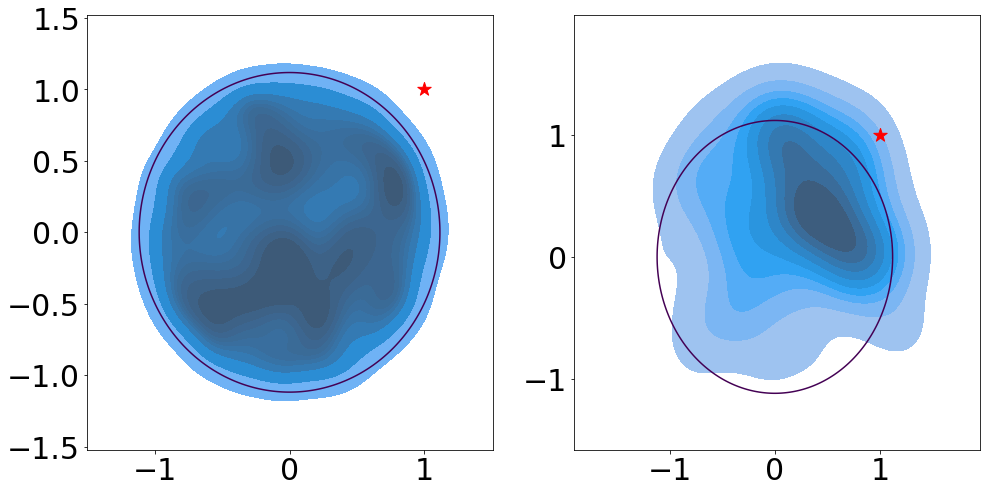

In [11]:

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)
X1 = np.linspace(-1.5, 1.5, 1000)
Y1 = np.linspace(-1.5, 1.5, 1000)
xx, yy = np.meshgrid(X1, Y1)
zz = np.power(np.power(np.abs(xx), lp) + np.power(np.abs(yy), lp), 1/lp)
for ax in axes:
    ax.contour(X1, Y1, zz, [s])
    ax.tick_params(labelsize=30)

sns.kdeplot(x=beta_xp, y=beta_yp, fill=True, levels=10, ax=axes[0])
sns.kdeplot(x=beta_xs, y=beta_ys, fill=True, levels=10, ax=axes[1])

# Plot star last with a high z-order
for ax in axes:
    ax.scatter(beta_star[0], beta_star[1], c='r', s=200, marker='*', zorder=10)

plt.savefig('images/prior_and_mysgld.png')

plt.show()
